# 19. Global, constrained, and network optimization

::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Example 13 pointed `optim_minimize()` at a custom likelihood with the six optimizers this package
shipped at the time. That list is now fourteen, and it covers three kinds of problem the earlier
six could not: a rough surface with many local minima, a problem with constraints on top of the
objective, and a problem whose derivative you can write down. This page works through all three,
then leaves the optimizers entirely for the shortest-path solver that shares their upstream
namespace.

## What you'll learn

- Four seeded global optimizers on the same hard surface, and how differently they spend their
  function evaluations.
- Why two of them miss the answer at their default settings, and what to change.
- Constrained minimization with `Constraint` and `method="augmented_lagrange"`, and what the
  Lagrange multiplier it reports actually tells you.
- That the choice of inner optimizer decides which local solution a constrained problem converges
  to.
- How supplying an analytic gradient to `"adam"` cuts its objective calls by a factor of eight.
- `shortest_path()`, the Dijkstra routing table, over a ten-node network.
- Which of these reproduce bit-for-bit across R, Python, and the original C# library, and which
  were measured not to.

## Setup

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import corehydropy as ch

## Four global optimizers on one hard surface

The Eggholder function is the standard torture test for a global optimizer: a lattice of deep
basins over $[-512, 512]^2$ with a global minimum of $-959.6407$ in the corner at
$(512, 404.2319)$, and dozens of local minima almost as deep. Its value at a point tells a local
method nothing about where to go next.

In [2]:
def eggholder(p):
    x, y = p[0], p[1]
    return (-(y + 47) * math.sin(math.sqrt(abs(x / 2 + (y + 47))))
            - x * math.sin(math.sqrt(abs(x - (y + 47)))))

All four stochastic global methods take the same arguments -- bounds and a seed -- so swapping
one for another is a one-word change:

In [3]:
methods = ["de", "particle_swarm", "sce", "simulated_annealing"]
runs = {
    m: ch.optim_minimize(eggholder, lower=[-512, -512], upper=[512, 512], method=m, seed=12345)
    for m in methods
}

print(f"{'method':<20} {'value':>12} {'x':>11} {'y':>11} {'evaluations':>12}")
for m in methods:
    r = runs[m]
    print(f"{m:<20} {r.value:12.4f} {r.parameters[0]:11.4f} {r.parameters[1]:11.5f}"
          f" {r.function_evaluations:12d}")

method                      value           x           y  evaluations
de                      -959.6407    512.0000   404.23175         1000
particle_swarm          -959.6407    512.0000   404.23181        72420
sce                     -935.3380    439.4810   453.97744         4663
simulated_annealing     -293.2958    180.8227    71.65686       800001


Two of the four land on the global minimum and two do not. Differential evolution gets there in
1,000 objective calls; particle swarm agrees with it to ten significant digits but spends 72,420
calls doing so. Shuffled complex evolution stops in a neighbouring basin at $-935.34$, and
simulated annealing ends up at $-293.30$, nowhere near.

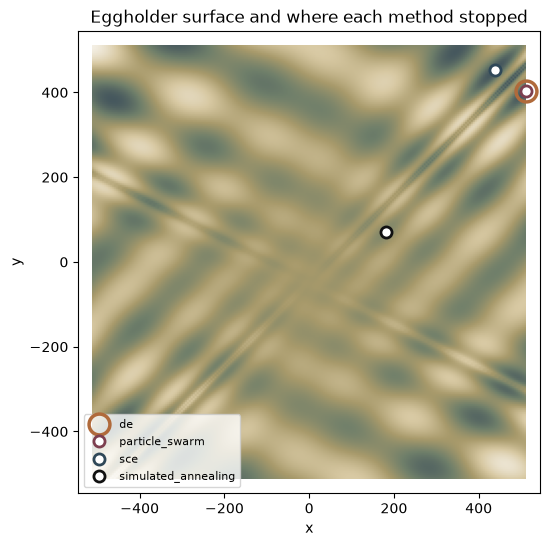

In [4]:
grid = np.linspace(-512, 512, 220)
gx, gy = np.meshgrid(grid, grid)
surface = (-(gy + 47) * np.sin(np.sqrt(np.abs(gx / 2 + (gy + 47))))
           - gx * np.sin(np.sqrt(np.abs(gx - (gy + 47)))))
ramp = LinearSegmentedColormap.from_list(
    "earth", ["#40525c", "#6f7f6a", "#a89a6b", "#d8c9a3", "#f4efe4"])

marks = {"de": "#b06a3b", "particle_swarm": "#7d3f4f", "sce": "#2f4858",
         "simulated_annealing": "#111111"}

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(surface, origin="lower", extent=(-512, 512, -512, 512), cmap=ramp, aspect="equal")
# de and particle_swarm converge to the same corner, so de is drawn last as a wider open ring
# around the others rather than a filled disc that would hide them.
for m in ["sce", "simulated_annealing", "particle_swarm"]:
    ax.plot(runs[m].parameters[0], runs[m].parameters[1], "o", markersize=8,
            markerfacecolor="white", markeredgecolor=marks[m], markeredgewidth=2, label=m)
ax.plot(runs["de"].parameters[0], runs["de"].parameters[1], "o", markersize=15,
        markerfacecolor="none", markeredgecolor=marks["de"], markeredgewidth=2.5, label="de")
ax.set_xlim(-545, 545)
ax.set_ylim(-545, 545)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Eggholder surface and where each method stopped")
handles, labels = ax.get_legend_handles_labels()
order = [labels.index(m) for m in methods]
ax.legend([handles[i] for i in order], [labels[i] for i in order], loc="lower left", fontsize=8)
plt.show()

Differential evolution and particle swarm are the two nested circles in the top right corner. The
other two stopped in basins that look, from inside them, exactly as good.

## The defaults are settings, not verdicts

Neither failure above is a verdict on the method. Shuffled complex evolution runs five complexes by
default; the upstream C# test for this exact function runs thirty, with ten evolution steps each,
and that run finds the corner:

In [5]:
sce_tuned = ch.optim_minimize(eggholder, lower=[-512, -512], upper=[512, 512], method="sce",
                              seed=12345, control={"complexes": 30, "cce_iterations": 10})
print(f"default {runs['sce'].value:.4f}   tuned {sce_tuned.value:.4f}   truth {-959.6407:.4f}")

default -935.3380   tuned -959.6407   truth -959.6407


Thirty complexes cost 77,685 objective calls against the default's 4,663, which is the trade: SCE
searches by keeping several populations apart long enough to explore separately, and five of them
are not enough separation for a surface this rough.

Simulated annealing is the more honest failure. Upstream's own test on this function asserts
nothing at all, under the comment that "simulated annealing fails to converge for this test
function ... this test is still included as an example". The port reproduces that failure exactly,
which is the point: a method with a fixed cooling schedule and 10,000 iterations of it will spend
its whole budget without ever getting cold enough near the right basin.

In [6]:
sa = runs["simulated_annealing"]
print(f"value {sa.value:.4f} after {sa.iterations} iterations and "
      f"{sa.function_evaluations} objective calls ({sa.status})")

value -293.2958 after 10000 iterations and 800001 objective calls (MaximumIterationsReached)


Eight hundred thousand objective calls, and the search ends 666 units of objective short of where
differential evolution finished in a thousand. Cost buys nothing if the schedule is wrong for the
surface.

## A constrained problem

Everything above minimizes over a box. `method="augmented_lagrange"` is the one method that takes
constraints on top of the box: it builds an augmented Lagrangian from the objective and the
constraint violations, and hands that to an inner optimizer, tightening the penalty until the
constraints hold.

Haimes problem 5.2 is the textbook case. Minimize

$$f(x, y) = (x - 2)^2 + (y - 4)^2 + 5$$

subject to $g(x, y) = (x - 6)^2 + (y - 10)^2 + 6 \le 13.31$. The unconstrained minimum sits at
$(2, 4)$, comfortably outside the feasible disk, so the constraint is binding and the answer must
lie on its boundary:

In [7]:
def primary(p):
    return (p[0] - 2) ** 2 + (p[1] - 4) ** 2 + 5


def secondary(p):
    return (p[0] - 6) ** 2 + (p[1] - 10) ** 2 + 6


feasible = ch.Constraint(secondary, value=13.31, type="le")
print(feasible)

haimes = ch.optim_minimize(primary, initial=[5, 5], lower=[0, 0], upper=[10, 10],
                           method="augmented_lagrange", constraints=[feasible])
print(f"x {haimes.parameters[0]:.6f}   y {haimes.parameters[1]:.6f}   "
      f"value {haimes.value:.6f}   constraint {secondary(haimes.parameters):.6f}")

<Constraint f(x) <= 13.31 (tolerance 1e-08)>
x 4.501394   y 7.749627   value 25.316672   constraint 13.310000


The solution sits on the constraint boundary, $g = 13.31$ to eight digits, at the point the C#
test asserts, $(4.5, 7.75)$ with an objective of $25.31$. A constrained method that stopped
anywhere inside the disk would be reporting a solution the constraint had not actually shaped.

The multiplier is what a penalty method gives you that a box does not:

In [8]:
haimes.multipliers

{'equality': array([], dtype=float64),
 'less_than': array([1.6665948]),
 'greater_than': array([], dtype=float64)}

`less_than` holds one entry per `"le"` constraint, in the order they were passed. Its value,
$1.667$, is the shadow price of the constraint: to first order, relaxing the bound by one unit
improves the objective by that much. Moving the bound from 13.31 to 14.31 puts the claim to the
test:

In [9]:
relaxed = ch.optim_minimize(primary, initial=[5, 5], lower=[0, 0], upper=[10, 10],
                            method="augmented_lagrange",
                            constraints=[ch.Constraint(secondary, value=14.31, type="le")])
print(f"tight {haimes.value:.6f}   relaxed {relaxed.value:.6f}   "
      f"saving {haimes.value - relaxed.value:.6f}   "
      f"multiplier {haimes.multipliers['less_than'][0]:.6f}")

tight 25.316672   relaxed 23.735008   saving 1.581665   multiplier 1.666595


The bound bought 1.58 against a predicted 1.67. The multiplier is a derivative and a whole unit is
a long step on a curved boundary, so the two agreeing to 5% is the prediction working, not failing.
Shrink the step and the gap shrinks with it.

## The inner optimizer picks the solution

The augmented Lagrangian is only as good as the optimizer minimizing it. By default that is BFGS
over the same bounds; `inner` swaps it for any other method, and on this problem the swap changes
the answer:

In [10]:
powell_inner = ch.optim_minimize(primary, initial=[5, 5], lower=[0, 0], upper=[10, 10],
                                 method="augmented_lagrange", constraints=[feasible],
                                 inner={"method": "powell"})

print(f"{'inner':<16} {'x':>10} {'y':>10} {'value':>10} {'multiplier':>12}")
for name, r in (("bfgs (default)", haimes), ("powell", powell_inner)):
    print(f"{name:<16} {r.parameters[0]:10.4f} {r.parameters[1]:10.4f} {r.value:10.4f}"
          f" {r.multipliers['less_than'][0]:12.6f}")

inner                     x          y      value   multiplier
bfgs (default)       4.5014     7.7496    25.3167     1.666595
powell               5.4794     7.3469    28.3078     3.511786


Both points are feasible and both are local solutions; Powell's is worse by three units of
objective. This is not a defect in either optimizer, and it is not a port artifact -- the real C#
library splits the same way on the same problem, which is why the fixture for the Powell run pins
its own numbers rather than the C# test's. It is the ordinary hazard of a non-convex constrained
problem: the constraint boundary has more than one point where the objective's gradient lines up
with it, and which one you get is decided by the inner search, not by the constraint.

## An analytic gradient

`"adam"` and `"gradient_descent"` are the two methods that follow a gradient. Given none, both
compute one by finite differences: one extra objective call per parameter per step. Given an
analytic gradient, they call it once per step instead.

The objective here is a separable quadratic with a known minimum at $(0.125, 0.2, 0.35)$ -- three
calibration parameters, each with its own target and its own sensitivity:

In [11]:
def fxyz(p):
    return (4 * p[0] - 0.5) ** 2 + (3 * p[1] - 0.6) ** 2 + (2 * p[2] - 0.7) ** 2


def fxyz_gradient(p):
    return [8 * (4 * p[0] - 0.5), 6 * (3 * p[1] - 0.6), 4 * (2 * p[2] - 0.7)]


numeric_run = ch.optim_minimize(fxyz, initial=[0.2, 0.5, 0.5], lower=[0, 0, 0], upper=[1, 1, 1],
                                method="adam")
analytic_run = ch.optim_minimize(fxyz, initial=[0.2, 0.5, 0.5], lower=[0, 0, 0], upper=[1, 1, 1],
                                 method="adam", gradient=fxyz_gradient)

print(f"{'gradient':<20} {'iterations':>11} {'objective calls':>16} {'value':>14}")
for name, r in (("finite difference", numeric_run), ("analytic", analytic_run)):
    print(f"{name:<20} {r.iterations:11d} {r.function_evaluations:16d} {r.value:14.6e}")

gradient              iterations  objective calls          value
finite difference           1516            12137   1.093709e-15
analytic                    1516             1518   1.093709e-15


Identical path, identical answer, 12,137 objective calls against 1,518. The two runs take the same
1,516 steps because ADAM's own arithmetic is unchanged; what changes is that the finite-difference
run pays eight calls a step to learn the gradient it was handed for free. On a three-parameter
quadratic that is a curiosity. On a likelihood over a long record it is the difference between a
fit that finishes and one you abandon.

The gradient is checked on the way in: return the wrong number of partials and the call fails
rather than optimizing something else.

In [12]:
try:
    ch.optim_minimize(fxyz, initial=[0.2, 0.5, 0.5], lower=[0, 0, 0], upper=[1, 1, 1],
                      method="adam", gradient=lambda p: [1, 2])
except Exception as err:
    print(f"{type(err).__name__}: {err}")

RuntimeError: the gradient must return one value per parameter; got a value of length 2 for 3 parameters


## Shortest paths through a network

`shortest_path()` is not an optimizer -- its input is a graph, not a function -- but it comes from
the same upstream namespace and answers the same kind of question. Given a directed, weighted
graph and one or more destinations, it runs Dijkstra's algorithm backwards from the destinations
and returns a routing table: for every node, which neighbour to step to, along which edge, and what
the remaining trip costs.

The graph is upstream's own routing test, two ranks of five nodes with a few rungs between them.
Node indices are 0-based in both packages, matching the C# table they share:

In [13]:
frm = [0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 9, 9]
to = [5, 1, 0, 2, 6, 7, 1, 3, 7, 2, 8, 4, 3, 9, 0, 6, 5, 1, 7, 6, 1, 2, 8, 7, 3, 9, 8, 4]
cost = [1, 30, 30, 1, 15, 2, 1, 5, 5, 5, 2, 1, 1, 30, 1, 3, 3, 15, 1, 1, 2, 5, 1, 1, 2, 2, 2, 30]
reach = [0, 1, 1, 2, 3, 4, 2, 5, 6, 5, 7, 8, 8, 9, 0, 10, 10, 3, 11, 11, 4, 6, 12, 12, 7, 13, 13, 9]

routes = ch.shortest_path(frm, to, cost, destinations=9, edge_index=reach)

print(f"{'node':>5} {'next_node':>10} {'edge_index':>11} {'cost':>6}")
for node, (next_node, edge_index, trip) in enumerate(routes):
    print(f"{node:5d} {int(next_node):10d} {int(edge_index):11d} {trip:6g}")

 node  next_node  edge_index   cost
    0          5           0      8
    1          7           4      5
    2          1           2      6
    3          8           7      4
    4          3           8      5
    5          6          10      7
    6          7          11      4
    7          8          12      3
    8          9          13      2
    9          9          -1      0


Read the table one row at a time. From node 0 the cheapest way to node 9 costs 8 and starts by
stepping to node 5 -- even though node 0 has a direct edge to node 1, which is one step closer to
the destination in hops. That edge costs 30 on its own, and the whole route through node 5
(0, 5, 6, 7, 8, 9) costs 8 in total. Hop count is not distance.

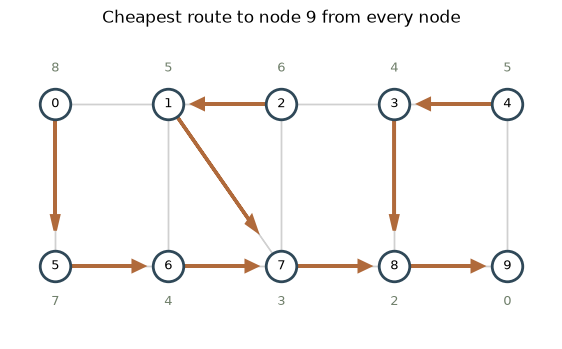

In [14]:
pos_x = list(range(5)) + list(range(5))
pos_y = [1] * 5 + [0] * 5

fig, ax = plt.subplots(figsize=(7, 4))
for a, b in zip(frm, to):
    ax.plot([pos_x[a], pos_x[b]], [pos_y[a], pos_y[b]], color="#d0d0d0", lw=1, zorder=1)
for node in range(10):
    nxt = int(routes[node][0])
    if nxt != node:
        x0, y0 = pos_x[node], pos_y[node]
        dx, dy = pos_x[nxt] - x0, pos_y[nxt] - y0
        # stop short of the target circle so the arrowhead stays visible
        ax.arrow(x0, y0, 0.78 * dx, 0.78 * dy, color="#b06a3b", lw=2.5,
                 head_width=0.06, length_includes_head=True, zorder=2)
for node in range(10):
    ax.plot(pos_x[node], pos_y[node], "o", markersize=22, markerfacecolor="white",
            markeredgecolor="#2f4858", markeredgewidth=2, zorder=3)
    ax.text(pos_x[node], pos_y[node], str(node), ha="center", va="center", fontsize=9, zorder=4)
    offset = 0.22 if pos_y[node] > 0.5 else -0.22
    ax.text(pos_x[node], pos_y[node] + offset, f"{routes[node][2]:g}", ha="center", va="center",
            fontsize=9, color="#6f7f6a")
ax.set_xlim(-0.4, 4.4)
ax.set_ylim(-0.45, 1.45)
ax.axis("off")
ax.set_title("Cheapest route to node 9 from every node")
plt.show()

Every arrow is one row of the table, and following them from any node walks the cheapest route to
node 9. The number beside each node is its cost to get there. Pass several `destinations` and each
node keeps whichever one it reaches most cheaply, which is how you route a whole basin to the
nearest of several outlets in one call.

## What reproduces across languages, and what does not

Most of this site can promise that a seeded run gives bit-identical numbers in R and Python,
because the work happens in the shared C++ core. The optimizer surface needs that promise stated
more carefully, in three tiers, and every tier below was measured rather than assumed.

**Deterministic, and bit-for-bit against C#.** `"adam"` and `"gradient_descent"` have no random
number generator at all, and reproduce the real C# library exactly -- including the evaluation
counts above, 12,137 and 1,518 -- with or without fused-multiply-add contraction in the compiler.
`shortest_path()` is the same: integer-and-single-precision arithmetic, reproducing C#'s routing
table bit-for-bit including its single-precision partial sums. `"augmented_lagrange"` has no
generator either, and reproduces C# to about $2 \times 10^{-9}$ on the constructs above, becoming
bit-identical when the core is compiled with `-ffp-contract=off` -- the whole residual is
contraction inside the inner BFGS.

**Seeded, and completely reproducing.** `"simulated_annealing"` and `"multi_start"` reproduce
across all four of C++, R, Python, and C#: iteration count, evaluation count, converged value, and
every parameter. `fixtures/toolbox/toolbox_cross_language.json` pins both at zero tolerance for
exactly that reason.

**Seeded, and reproducing across the two packages but not necessarily against C#.**
`"particle_swarm"` and `"sce"` branch on comparisons between accumulated sums, and clang and gcc
contract `a * b + c` into a fused multiply-add by default where .NET never does. One contracted
expression can flip an accept-or-reject and every draw after it is spent differently. Measured:
particle swarm on the Booth function takes 3,073 iterations and 92,220 evaluations both in the real
C# library and in an uncontracted C++ build, against 3,855 and 115,680 in a contracted one. So the
same fixture pins, for particle swarm on Eggholder, only what survives both paths -- the iteration
count, the evaluation count, the converged value, and the parameter that lands exactly on the
bound -- and for SCE only the counts and the status. Nothing was skipped and no tolerance was
loosened to get there; the unreproducible quantities are simply not asserted, and each run's
accuracy is pinned separately against the upstream test's own literals.

Underneath all three tiers sits the limit example 13 established, which has not changed: a seeded
run's parameters come from the shared C++ generator and reproduce, while the reported objective
*value* comes from re-evaluating your own R or Python code, and the two languages do not guarantee
identical rounding for the same formula. On this page they happen to agree to the last bit on every
construct, which is common and is not a guarantee.

## Key takeaways

1. The four seeded global methods differ by more than an order of magnitude in what they spend and
   by hundreds of units of objective in what they find. Try more than one before believing any of
   them.
2. `control` is where a global method's search strategy lives. Shuffled complex evolution finds the
   Eggholder minimum at thirty complexes and misses it at five; the code is identical.
3. `Constraint` plus `method="augmented_lagrange"` puts constraints on top of the box, and reports
   the multiplier that prices each one.
4. `inner` decides which local solution a constrained non-convex problem converges to. Change it
   and check whether the answer moved.
5. An analytic gradient turns a per-parameter finite-difference bill into one call a step -- an
   eightfold cut on three parameters, more on more.
6. `shortest_path()` answers routing questions for a whole network at once, and the cheapest route
   is rarely the one with the fewest hops.

## Reproduction check

Four groups, kept separate. Values pinned against the upstream C# MSTest literals carry that test's
own tolerance. Values read off the real C# library by the dotnet oracle gate carry the tolerance
the matching fixture uses. This page's own deterministic numbers are checked directly. The particle
swarm and simulated annealing runs are pinned exactly, but only on the quantities
`fixtures/toolbox/toolbox_cross_language.json` itself pins -- particle swarm's second parameter is
deliberately absent here for the reason given above.

In [15]:
# Upstream MSTest literals, at the C# test's own tolerance.
assert abs(sce_tuned.value - -959.6407) < 1e-4              # SCE Test_Eggholder
assert abs(sce_tuned.parameters[0] - 512) < 1e-3
assert abs(sce_tuned.parameters[1] - 404.2319) < 1e-3
assert abs(runs["de"].value - -959.6407) < 1e-4             # the textbook optimum
assert abs(haimes.parameters[0] - 4.5) < 1e-2               # AL Test_Haimes_5_2
assert abs(haimes.parameters[1] - 7.75) < 1e-2
assert abs(haimes.value - 25.31) < 1e-2
assert abs(haimes.multipliers["less_than"][0] - 1.67) < 1e-2
assert abs(numeric_run.value - 0) < 1e-4                    # ADAM Test_FXYZ
assert abs(analytic_run.parameters[0] - 0.125) < 1e-4
assert abs(analytic_run.parameters[2] - 0.35) < 1e-4

# Read off the REAL C# library by the dotnet oracle gate.
assert abs(powell_inner.parameters[0] - 5.4793811558833845) < 1e-6
assert abs(powell_inner.value - 28.30781213770569) < 1e-6
assert abs(powell_inner.multipliers["less_than"][0] - 3.511785881316314) < 1e-6
assert numeric_run.function_evaluations == 12137
assert analytic_run.function_evaluations == 1518
assert analytic_run.iterations == 1516

# Seeded, and measured to reproduce exactly in C++, R, Python and C#.
assert runs["particle_swarm"].iterations == 2413
assert runs["particle_swarm"].function_evaluations == 72420
assert runs["particle_swarm"].value == -959.640662720851
assert runs["particle_swarm"].parameters[0] == 512.0
assert runs["simulated_annealing"].value == -293.29583227407102
assert runs["simulated_annealing"].iterations == 10000

# The Dijkstra routing table, asserted by exact equality as the C# test asserts it.
assert list(routes[:, 2]) == [8, 5, 6, 4, 5, 7, 4, 3, 2, 0]
assert list(routes[:, 0]) == [5, 7, 1, 8, 3, 6, 7, 8, 9, 9]

# This page's own deterministic numbers.
assert haimes.value == 25.316672218251753
assert abs(secondary(haimes.parameters) / 13.31 - 1) < 1e-9
assert numeric_run.value == 1.0937092922988765e-15

print("All reproduction checks passed.")

All reproduction checks passed.
